<a href="https://colab.research.google.com/github/aliabusohiban/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_SalesFINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 Prediction of Product Sales — Machine Learning Project
**Author:** Ali Abu Sohiban
**Dataset:** `sales_predictions_2023.csv`
**Goal:** Build and compare regression models to predict product sales at retail outlets.

---

## Table of Contents
1. [Imports & Setup](#1-imports--setup)
2. [Load Data](#2-load-data)
3. [Data Cleaning](#3-data-cleaning)
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis-eda)
5. [Feature Inspection](#5-feature-inspection)
6. [Train / Test Split](#6-train--test-split)
7. [Preprocessing Pipeline](#7-preprocessing-pipeline)
8. [Model Training & Evaluation](#8-model-training--evaluation)
9. [Model Comparison Summary](#9-model-comparison-summary)
10. [Linear Regression — Coefficients](#10-linear-regression--coefficients)
11. [Random Forest — Feature Importances](#11-random-forest--feature-importances)


## 1. Imports & Setup

Import all necessary libraries for data processing, visualization, and machine learning.

In [77]:
# ── Core libraries ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn preprocessing & utilities ─────────────────────────────────────────
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# ── Models ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

set_config(transform_output='pandas')

SEED      = 42
DATA_PATH = '/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv'

print('✅ All imports successful.')

✅ All imports successful.


## 2. Helper Functions

These reusable functions handle model evaluation throughout the notebook.
`evaluate_regression` scores a model on both train and test sets, printing
a full metrics report so we can spot overfitting at a glance.

In [78]:
def regression_metrics(y_true, y_pred, label='', verbose=True, output_dict=False):
    """Print MAE, MSE, RMSE, R² for a set of predictions."""
    mae       = mean_absolute_error(y_true, y_pred)
    mse       = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r_squared = r2_score(y_true, y_pred)

    if verbose:
        header = '-' * 60
        print(header, f'Regression Metrics: {label}', header, sep='\n')
        print(f'- MAE  = {mae:,.3f}')
        print(f'- MSE  = {mse:,.3f}')
        print(f'- RMSE = {rmse:,.3f}')
        print(f'- R^2  = {r_squared:,.3f}')

    if output_dict:
        return {'Label': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R^2': r_squared}


def evaluate_regression(reg, X_train, y_train, X_test, y_test,
                         verbose=True, output_frame=False):
    """Evaluate a fitted pipeline on both the training and test sets."""
    y_train_pred  = reg.predict(X_train)
    results_train = regression_metrics(y_train, y_train_pred, label='Training Data',
                                       verbose=verbose, output_dict=output_frame)
    print()
    y_test_pred  = reg.predict(X_test)
    results_test = regression_metrics(y_test, y_test_pred, label='Test Data',
                                      verbose=verbose, output_dict=output_frame)
    if output_frame:
        results_df = pd.DataFrame([results_train, results_test])
        results_df = results_df.set_index('Label')
        results_df.index.name = None
        return results_df.round(3)


def show_best_params(grid):
    """Pretty-print the winning hyperparameters from a GridSearchCV object."""
    print(f'Best R² (CV): {grid.best_score_:.4f}')
    print('Best hyperparameters:')
    for k, v in grid.best_params_.items():
        print(f'  {k}: {v}')


print('✅ Helper functions defined.')

✅ Helper functions defined.


## 3. Load Data

Load the dataset from Google Drive. After loading, we take a first look at the shape,
column names, and sample rows to orient ourselves before cleaning.

In [79]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [80]:
df_sales = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df_sales.shape}')
df_sales.head(10)

Dataset shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


## 4. Data Cleaning

### 4.1 Inspect Data Types & Missing Values

First, we inspect each column's data type and count of non-null values.
This gives us a map of what needs fixing before analysis.

In [81]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


We have 8523 rows and 12 columns.


*   7 categorical columns.
*   5 numerical columns.

### 4.2 Check for Duplicates

In [82]:
df_sales.duplicated().sum()

np.int64(0)

We don't have any duplicated values.

### 4.3 Inspect Missing Values

In [83]:
missing = df_sales.isna().sum()
missing_pct = (missing / len(df_sales) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_summary.to_string())

             Missing Count  Missing %
Outlet_Size           2410      28.28
Item_Weight           1463      17.17


We see that we have missing values in tow columns:

*   1463 missng value in `Item_Weight`
*   2410 missing value in `Outlet_Size`

### 4.4 Inspect & Fix Categorical Columns

We check every string column for inconsistent or unexpected values
(typos, wrong casing) before treating them as real nulls.

In [84]:
string_cols = df_sales.select_dtypes('object').columns
for col in string_cols:
    print(f'\n── Value Counts: {col} ──')
    print(df_sales[col].value_counts(dropna=False))


── Value Counts: Item_Identifier ──
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64

── Value Counts: Item_Fat_Content ──
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

── Value Counts: Item_Type ──
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

── Value Counts: Outlet_Identifier ──
Outlet_Identifier
OUT027    

Here we find the data type for each variable:

In [85]:
df_sales.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


We see that there is 3 wrong values, we must replace it by a the original ones.

In [86]:
df_sales['Item_Fat_Content'] = (df_sales['Item_Fat_Content']
    .replace('LF', 'Low Fat')
    .replace('reg', 'Regular')
    .replace('low fat', 'Low Fat'))

print('✅ Item_Fat_Content after fix:')
print(df_sales['Item_Fat_Content'].value_counts())

✅ Item_Fat_Content after fix:
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


Below we show the counts for every categorical column, to check for inconsistencies in it.
> We found that there is no inconsistencies in the columns.

In [87]:
for col in string_cols:
    print(f'Value Counts for {col}')
    print(df_sales[col].value_counts())
    print('\n')

Value Counts for Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


Value Counts for Item_Fat_Content
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


Value Counts for Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


Value Counts for Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    93

### 4.5 Inspect Numeric Columns

Below we have a summery statistics for every numerical column.

In [88]:
numeric_cols = df_sales.select_dtypes('number').columns
print('=== Statistical Summary ===\n')
for col in numeric_cols:
    print(f'{col}:')
    print(f'  Mean:    {df_sales[col].mean():.4f}')
    print(f'  Maximum: {df_sales[col].max():.4f}')
    print(f'  Minimum: {df_sales[col].min():.4f}')
    print()

=== Statistical Summary ===

Item_Weight:
  Mean:    12.8576
  Maximum: 21.3500
  Minimum: 4.5550

Item_Visibility:
  Mean:    0.0661
  Maximum: 0.3284
  Minimum: 0.0000

Item_MRP:
  Mean:    140.9928
  Maximum: 266.8884
  Minimum: 31.2900

Outlet_Establishment_Year:
  Mean:    1997.8319
  Maximum: 2009.0000
  Minimum: 1985.0000

Item_Outlet_Sales:
  Mean:    2181.2889
  Maximum: 13086.9648
  Minimum: 33.2900



This is the describe for the data after claening.

In [89]:
df_sales.describe().round(2)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.00,8523.00,8523.00,8523.00,8523.00
mean,12.86,0.07,140.99,1997.83,2181.29
std,4.64,0.05,62.28,8.37,1706.50
min,4.56,0.00,31.29,1985.00,33.29
25%,8.77,0.03,93.83,1987.00,834.25
50%,12.60,0.05,143.01,1999.00,1794.33
75%,16.85,0.09,185.64,2004.00,3101.30
max,21.35,0.33,266.89,2009.00,13086.96


## 5. Exploratory Data Analysis (EDA)

### 5.1 Univariate EDA — Plotting Functions

Two helper functions visualise individual columns.
`explore_categorical` shows a count plot with null info.
`explore_numeric` shows a histogram + boxplot pair with mean/median lines.

In [90]:
def explore_categorical(df, x, fillna=True, placeholder='MISSING',
                        figsize=(6, 4), order=None):
    """Count plot for a categorical column with null diagnostics."""
    temp_df = df.copy()
    null_count = temp_df[x].isna().sum()
    null_perc  = null_count / len(temp_df) * 100
    if fillna:
        temp_df[x] = temp_df[x].fillna(placeholder)

    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=figsize)
    sns.countplot(data=temp_df, x=x, ax=ax, order=order, palette='viridis')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(f'Column: {x}', fontweight='bold')
    fig.tight_layout()
    plt.show()

    print(f"- NaN's Found: {null_count} ({round(null_perc, 2)}%)")
    nunique = temp_df[x].nunique()
    print(f'- Unique Values: {nunique}')
    val_counts = temp_df[x].value_counts(dropna=False)
    most_common_val = val_counts.index[0]
    freq = val_counts.values[0]
    perc_most_common = freq / len(temp_df) * 100
    print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common, 2)}%)")
    if perc_most_common > 98:
        print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
    else:
        print('- Not constant or quasi-constant.')
    return fig, ax


def explore_numeric(df, x, figsize=(6, 5)):
    """Histogram + boxplot for a numeric column with null diagnostics."""
    null_count = df[x].isna().sum()
    null_perc  = null_count / len(df) * 100

    gridspec = {'height_ratios': [0.7, 0.3]}
    fig, axes = plt.subplots(nrows=2, figsize=figsize, sharex=True, gridspec_kw=gridspec)

    sns.histplot(data=df, x=x, bins=30, color='#4cc9f0', edgecolor='white', ax=axes[0])
    mean_val = df[x].mean()
    med_val  = df[x].median()
    axes[0].axvline(mean_val, color='red',    ls='--', label=f'Mean   = {mean_val:,.2f}')
    axes[0].axvline(med_val,  color='yellow', ls='--', label=f'Median = {med_val:,.2f}')
    axes[0].legend()
    axes[0].grid(axis='y', linestyle='--', alpha=0.3)
    axes[1].grid(axis='x', linestyle='--', alpha=0.3)

    sns.boxplot(data=df, x=x, ax=axes[1], color='#4cc9f0')
    axes[0].set_title(f'Column: {x}', fontweight='bold')
    fig.tight_layout()
    plt.show()

    print(f"- NaN's Found: {null_count} ({round(null_perc, 2)}%)")
    print(f'- Unique Values: {df[x].nunique()}')
    val_counts = df[x].value_counts(dropna=False)
    most_common_val = val_counts.index[0]
    freq = val_counts.values[0]
    perc_most_common = freq / len(df) * 100
    print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common, 2)}%)")
    if perc_most_common > 98:
        print(f"\n- [!] Warning: '{x}' is quasi-constant and should be dropped.")
    else:
        print('- Not constant or quasi-constant.')
    return fig, axes


print('✅ EDA plotting functions defined.')

✅ EDA plotting functions defined.


### 5.2 Categorical Features — Univariate

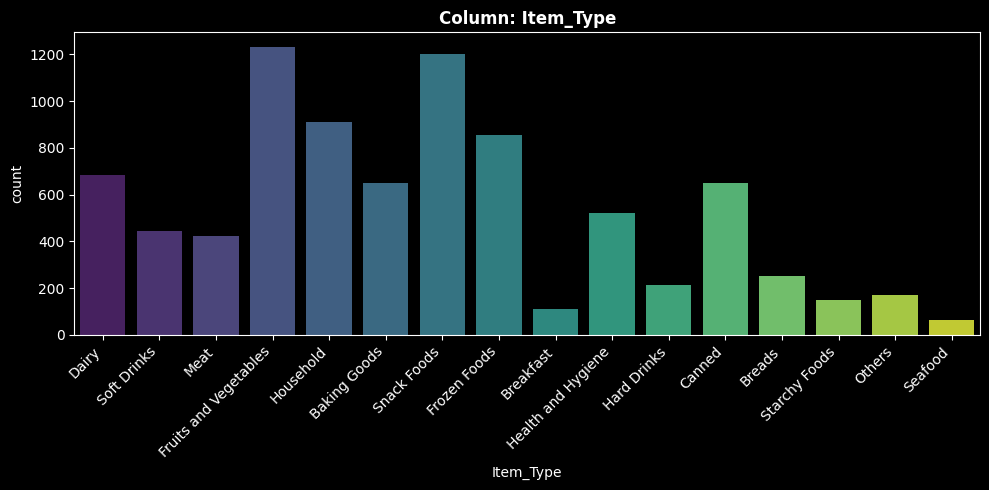

- NaN's Found: 0 (0.0%)
- Unique Values: 16
- Most common value: 'Fruits and Vegetables' occurs 1232 times (14.46%)
- Not constant or quasi-constant.


In [91]:
explore_categorical(df_sales, 'Item_Type', figsize=(10, 5));

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical (nominal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0 null values.
  - No need to impute.

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 16 unique categories.
  - High cardinality

5. Would we know this BEFORE the target is determined?
  - No.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

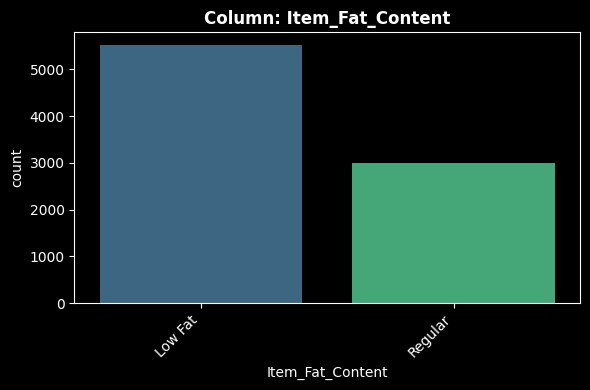

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Low Fat' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


In [92]:
explore_categorical(df_sales, 'Item_Fat_Content');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical (ordinal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0. Nothing to impute.

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 2 unique values (very low).

5. Would we know this BEFORE the target is determined?
  - No.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

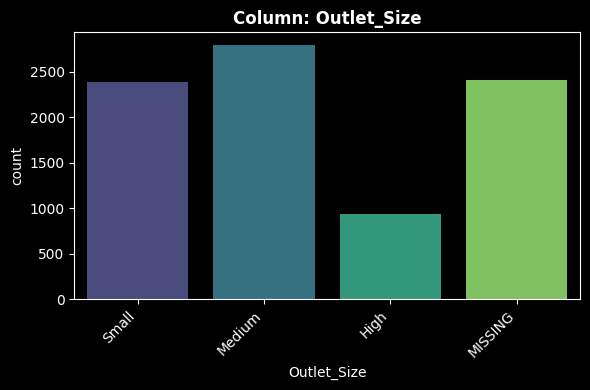

- NaN's Found: 2410 (28.28%)
- Unique Values: 4
- Most common value: 'Medium' occurs 2793 times (32.77%)
- Not constant or quasi-constant.


In [93]:
order_size = ['Small', 'Medium', 'High', 'MISSING']
explore_categorical(df_sales, 'Outlet_Size', order=order_size);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical (ordinal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 2410 null values (28.28%).
  - We will impute MISSING.

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 4 unique values (low).

5. Would we know this BEFORE the target is determined?
  - No.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

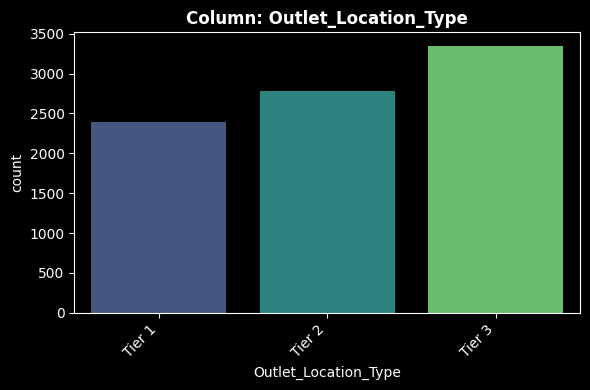

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'Tier 3' occurs 3350 times (39.31%)
- Not constant or quasi-constant.


In [94]:
order_tier = ['Tier 1', 'Tier 2', 'Tier 3']
explore_categorical(df_sales, 'Outlet_Location_Type', order=order_tier);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0. Nothing to impute.

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 3 unique values (very low).

5. Would we know this BEFORE the target is determined?
  - No.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

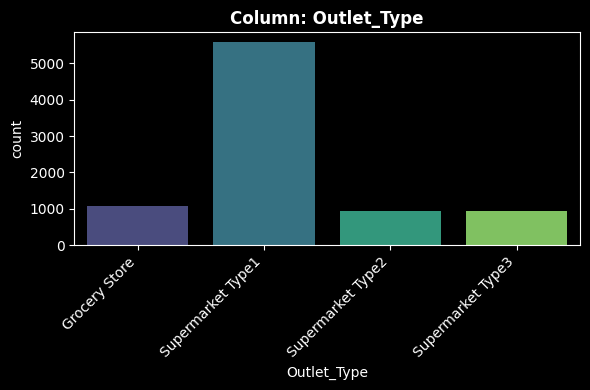

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'Supermarket Type1' occurs 5577 times (65.43%)
- Not constant or quasi-constant.


In [95]:
order_super = ['Grocery Store', 'Supermarket Type1', 'Supermarket Type2', 'Supermarket Type3']
explore_categorical(df_sales, 'Outlet_Type', order=order_super);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical(ordinal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0. Nothing to impute.

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 4 unique values (low).

5. Would we know this BEFORE the target is determined?
  - No.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

### 5.3 Numeric Features — Univariate

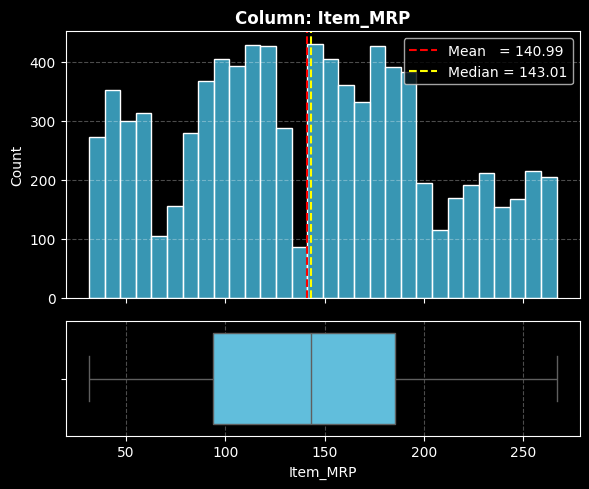

- NaN's Found: 0 (0.0%)
- Unique Values: 5938
- Most common value: '172.0422' occurs 7 times (0.08%)
- Not constant or quasi-constant.


In [96]:
explore_numeric(df_sales, 'Item_MRP');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0. Nothing to impute.

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - No cardinality.

5. Would we know this BEFORE the target is determined?
  - No.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

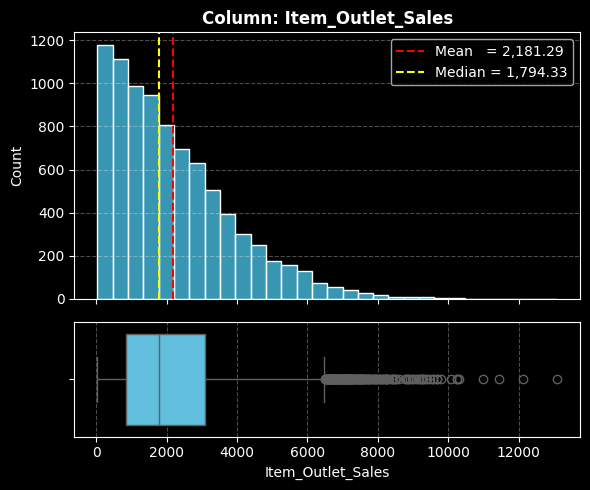

- NaN's Found: 0 (0.0%)
- Unique Values: 3493
- Most common value: '958.752' occurs 17 times (0.2%)
- Not constant or quasi-constant.


In [97]:
explore_numeric(df_sales, 'Item_Outlet_Sales');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0. Nothing to impute.

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - No cardinality.

5. Would we know this BEFORE the target is determined?
  - No.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

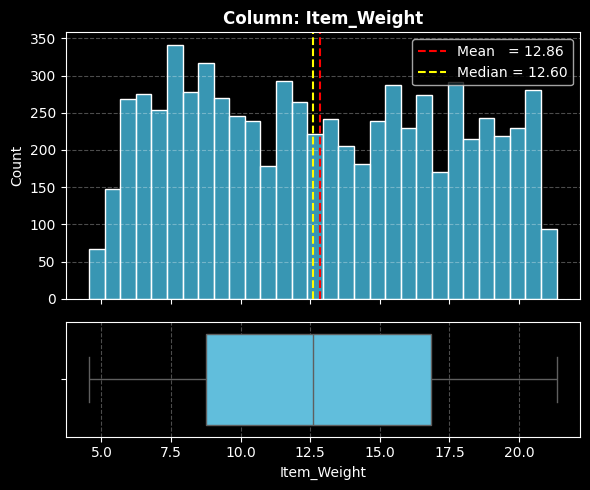

- NaN's Found: 1463 (17.17%)
- Unique Values: 415
- Most common value: 'nan' occurs 1463 times (17.17%)
- Not constant or quasi-constant.


In [98]:
explore_numeric(df_sales, 'Item_Weight');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 1463 nulls (17.17%), we will impute -1

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - No cardinality.

5. Would we know this BEFORE the target is determined?
  - No.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

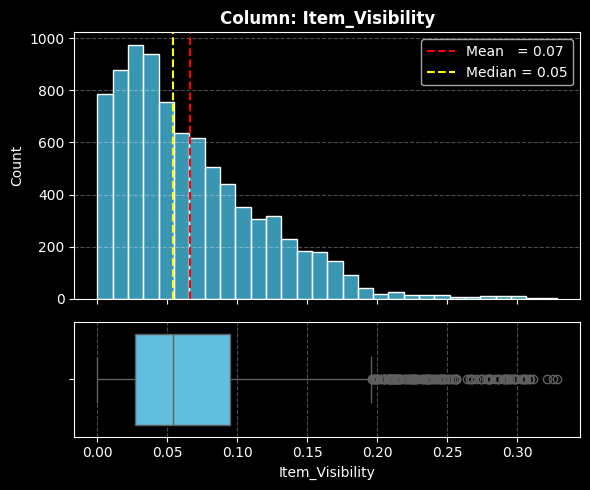

- NaN's Found: 0 (0.0%)
- Unique Values: 7880
- Most common value: '0.0' occurs 526 times (6.17%)
- Not constant or quasi-constant.


In [99]:
explore_numeric(df_sales, 'Item_Visibility');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0. Nothing to impute.

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - No cardinality.

5. Would we know this BEFORE the target is determined?
  - No.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

### 5.4 Correlation Heatmap

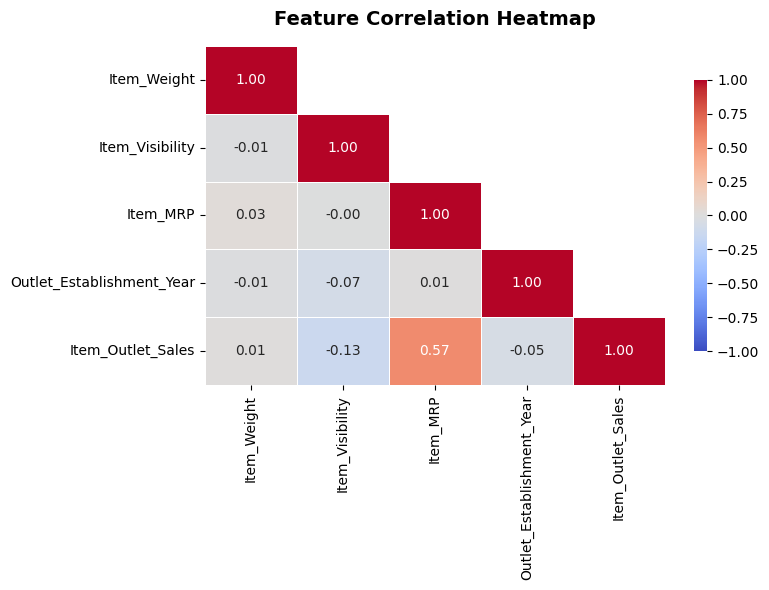

In [100]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_sales.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True,
            fmt='.2f', linewidths=0.5, vmin=-1, vmax=1, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 6. Feature Inspection

### 6.1 Multivariate EDA — Plotting Function

The function below plots each feature against the target:
a bar plot showing mean sales per category, with individual points overlaid.

In [101]:
def plot_categorical_vs_target(df, x, y='Item_Outlet_Sales', figsize=(10, 5),
                               fillna=True, placeholder='MISSING', order=None):
    """Bar + strip plot of a categorical feature vs. numeric target."""
    temp_df = df.copy()
    if fillna:
        temp_df[x] = temp_df[x].fillna(placeholder)
    else:
        temp_df = temp_df.dropna(subset=[x])

    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order,
                alpha=0.6, linewidth=1, edgecolor='black', errorbar=None)
    sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                  order=order, hue_order=order, legend=False,
                  edgecolor='white', linewidth=0.5, size=3, zorder=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(f'{x} vs. {y}', fontweight='bold')
    fig.tight_layout()
    return fig, ax


def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales', figsize=(6, 4)):
    """Scatter + regression line of a numeric feature vs. target."""
    r = df[[x, y]].corr().loc[x, y]
    fig, ax = plt.subplots(figsize=figsize)
    sns.regplot(data=df, x=x, y=y, ax=ax,
                scatter_kws={'ec': 'white', 'alpha': 0.8},
                line_kws={'color': 'orange'})
    ax.set_title(f'{x} vs. {y}  (r = {r:.2f})', fontweight='bold')
    plt.show()
    return fig, ax


print('✅ Multivariate plotting functions defined.')

✅ Multivariate plotting functions defined.


### 6.2 Categorical Features vs. Target

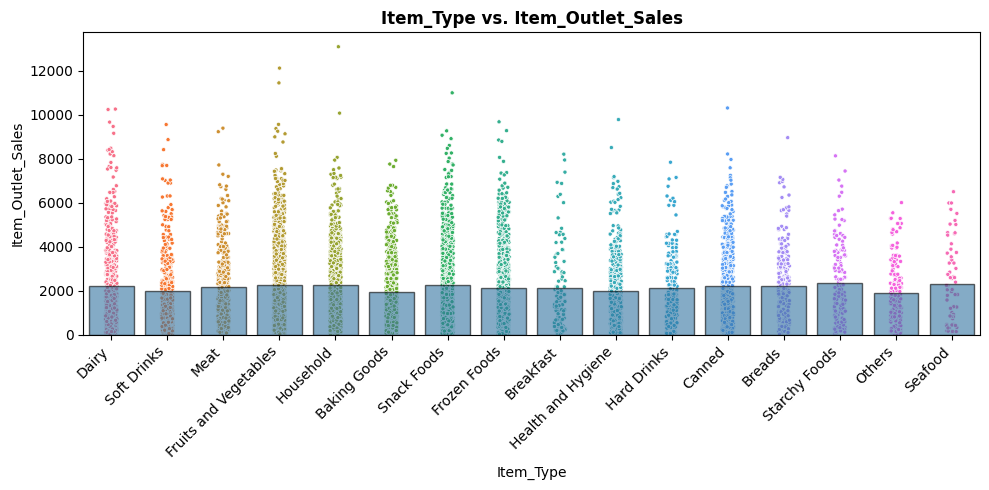

In [102]:
plot_categorical_vs_target(df_sales, 'Item_Type');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No
  - Does this feature appear to be a predictor of the target?
    - No

___

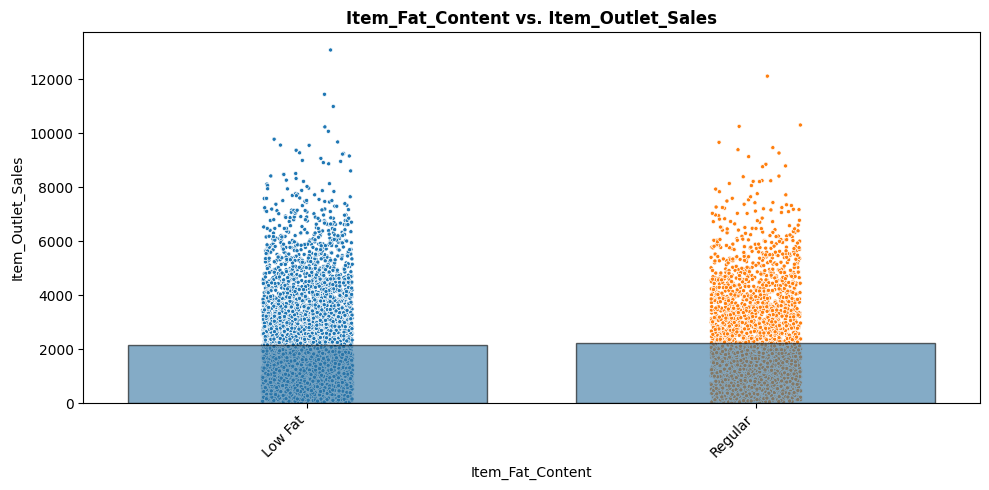

In [103]:
plot_categorical_vs_target(df_sales, 'Item_Fat_Content');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes. low fat products tend to be slightly higher in price.
  - Does this feature appear to be a predictor of the target?
    - No, the to values are very close to each other.

___

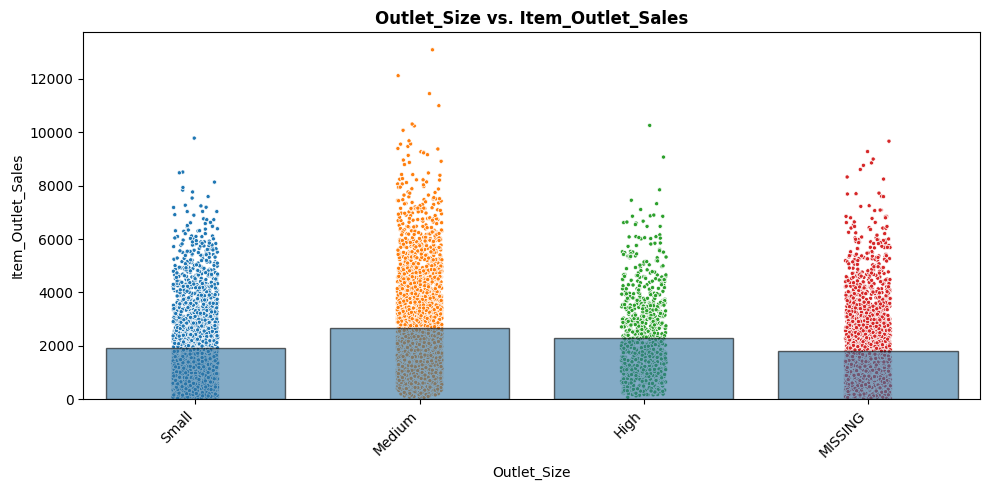

In [104]:
order_size = ['Small', 'Medium', 'High', 'MISSING']
plot_categorical_vs_target(df_sales, 'Outlet_Size', order=order_size);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, I think the medium size markets tend to sell with higher prices.
  - Does this feature appear to be a predictor of the target?
    - Yes.

___

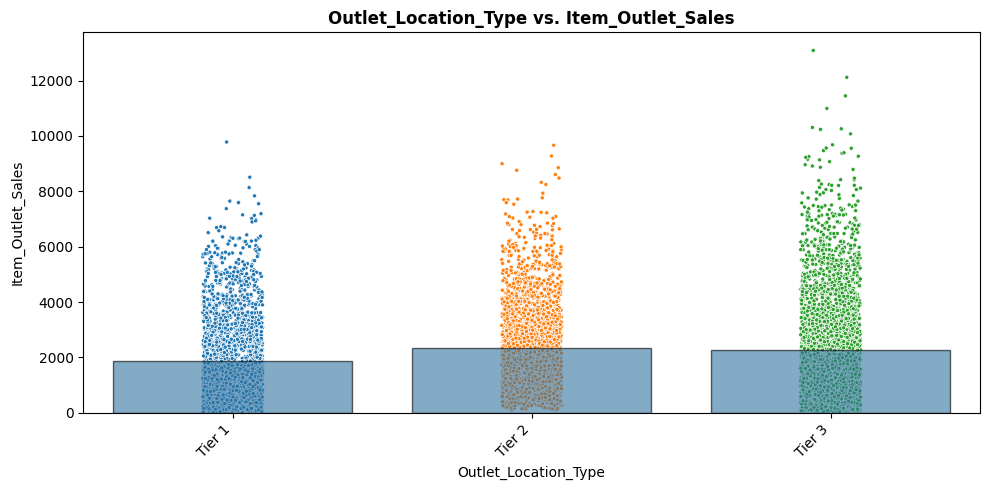

In [105]:
order_tier = ['Tier 1', 'Tier 2', 'Tier 3']
plot_categorical_vs_target(df_sales, 'Outlet_Location_Type', order=order_tier);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes
  - Does this feature appear to be a predictor of the target?
    - Yes

___

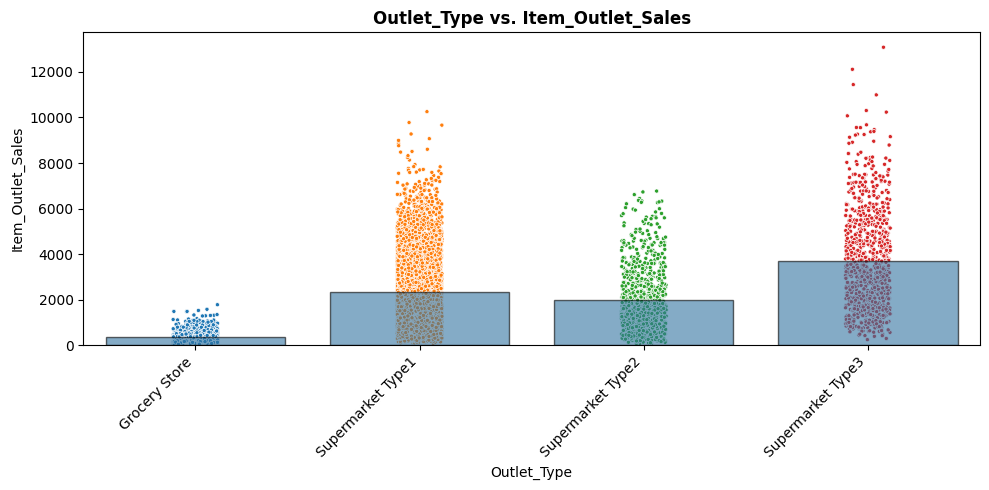

In [106]:
order_super = ['Grocery Store', 'Supermarket Type1', 'Supermarket Type2', 'Supermarket Type3']
plot_categorical_vs_target(df_sales, 'Outlet_Type', order=order_super);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes.
  - Does this feature appear to be a predictor of the target?
    - Yes.

___

### 6.3 Numeric Features vs. Target

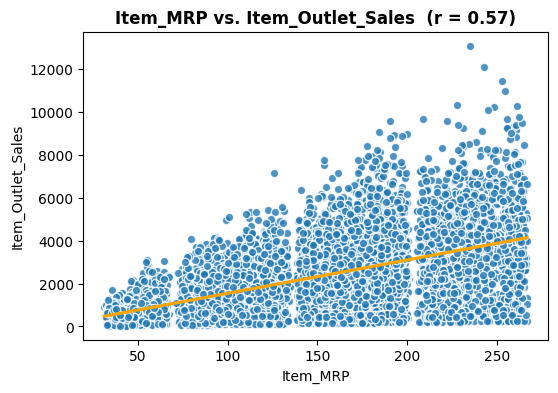

In [107]:
plot_numeric_vs_target(df_sales, 'Item_MRP');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes. there is a positve corrleation here.
  - Does this feature appear to be a predictor of the target?
    - Yes.

___

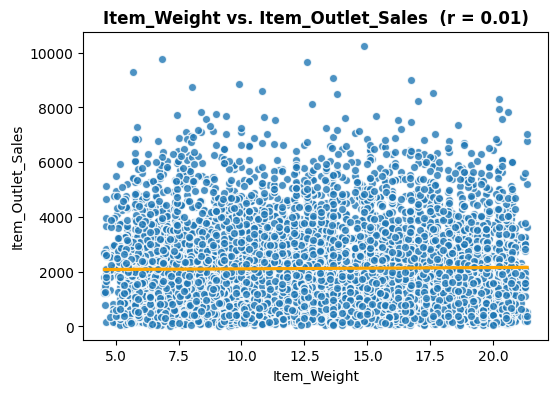

In [108]:
plot_numeric_vs_target(df_sales, 'Item_Weight');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - no.
  - Does this feature appear to be a predictor of the target?
    - no.

___

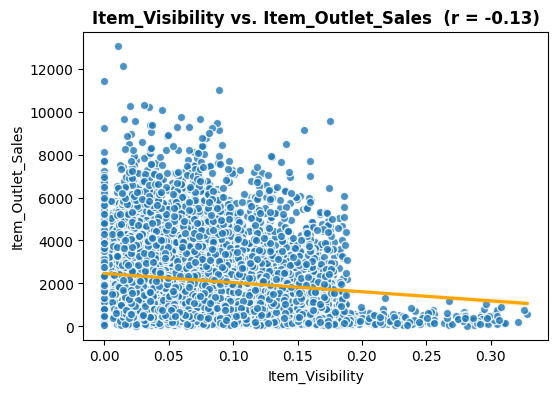

In [109]:
plot_numeric_vs_target(df_sales, 'Item_Visibility');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - yes.
  - Does this feature appear to be a predictor of the target?
    - yes.

___

## 7. Train / Test Split

We split the data **before** any imputation or encoding to prevent data leakage.

In [110]:
DROP_COLS = ['Item_Identifier', 'Outlet_Identifier']
TARGET    = 'Item_Outlet_Sales'

df = df_sales.drop(columns=DROP_COLS)
X  = df.drop(columns=TARGET)
y  = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=SEED)
print(f'Train shape : {X_train.shape}')
print(f'Test  shape : {X_test.shape}')

Train shape : (6392, 9)
Test  shape : (2131, 9)


## 8. Preprocessing Pipeline

### Justification of Encoding Strategy

| Column type | Encoder | Reason |
|---|---|---|
| `Item_Fat_Content`, `Outlet_Size`, `Outlet_Location_Type`, `Outlet_Type` | **OrdinalEncoder** | These have a natural, meaningful order. Preserving it lets tree-based models make better splits. |
| `Item_Type` | **OneHotEncoder** | No natural order — OHE creates a binary indicator without imposing an arbitrary ranking. |
| Numeric cols | **SimpleImputer → StandardScaler** | Median imputation is robust to skewed distributions. Scaling is required by distance-based and linear models. |

All transformations are fit **only on training data** and applied to the test set to avoid data leakage.

In [111]:
# ── Define column groups ────────────────────────────────────────────────────────
ORD_COLS = ['Item_Fat_Content', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
OHE_COLS = (
    X_train.select_dtypes('object')
    .drop(columns=ORD_COLS)
    .columns.tolist()
)
NUM_COLS = X_train.select_dtypes('number').columns.tolist()

print('Ordinal columns :', ORD_COLS)
print('OHE columns     :', OHE_COLS)
print('Numeric columns :', NUM_COLS)

Ordinal columns : ['Item_Fat_Content', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
OHE columns     : ['Item_Type']
Numeric columns : ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']


In [112]:
# ── Ordinal sub-pipeline ────────────────────────────────────────────────────────
ORDINAL_ORDERS = [
    ['Low Fat', 'Regular'],                                                               # Item_Fat_Content
    ['Small', 'Medium', 'High'],                                                          # Outlet_Size
    ['Tier 1', 'Tier 2', 'Tier 3'],                                                       # Outlet_Location_Type
    ['Grocery Store', 'Supermarket Type1', 'Supermarket Type2', 'Supermarket Type3'],     # Outlet_Type
]

ord_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OrdinalEncoder(categories=ORDINAL_ORDERS,
                   handle_unknown='use_encoded_value', unknown_value=-1),
    StandardScaler(),
)

# ── Nominal sub-pipeline ────────────────────────────────────────────────────────
ohe_pipe = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='MISSING'),
    OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'),
)

# ── Numeric sub-pipeline ────────────────────────────────────────────────────────
num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
)

# ── Assemble full preprocessor ──────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric',     num_pipe, NUM_COLS),
        ('ordinal',     ord_pipe, ORD_COLS),
        ('categorical', ohe_pipe, OHE_COLS),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)
print('✅ Preprocessing pipeline assembled.')

✅ Preprocessing pipeline assembled.


## 9. Model Training & Evaluation

### Why `R²` as the primary scoring metric?
R² (coefficient of determination) tells us the proportion of variance in sales that our
model explains. It is the standard metric for regression and gives an intuitive 0–1 scale.
We also report MAE and RMSE because they are in the same units as the target (sales dollars),
making them easier to communicate to stakeholders.

### 9.1 Model 1: Linear Regression

Linear Regression fits a weighted sum of features to minimise the mean squared error.
It is fast, interpretable via coefficients, and is a strong baseline for regression tasks.

In [113]:
# ── Default Linear Regression ──────────────────────────────────────────────────
linreg_pipe = make_pipeline(preprocessor, LinearRegression())
linreg_pipe.fit(X_train, y_train)
evaluate_regression(linreg_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE  = 909.490
- MSE  = 1,457,291.386
- RMSE = 1,207.183
- R^2  = 0.508

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE  = 871.409
- MSE  = 1,360,051.599
- RMSE = 1,166.213
- R^2  = 0.507


### 9.2 Model 2: Random Forest (Default)

Random Forest builds an ensemble of decision trees on random subsets of the data
and features. It handles non-linear relationships and mixed data types well,
and is typically more accurate than a single linear model on tabular retail data.

In [114]:
# ── Default Random Forest ───────────────────────────────────────────────────────
rf_pipe = make_pipeline(preprocessor, RandomForestRegressor(random_state=SEED))
rf_pipe.fit(X_train, y_train)
evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE  = 298.134
- MSE  = 184,609.893
- RMSE = 429.663
- R^2  = 0.938

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE  = 775.869
- MSE  = 1,249,963.206
- RMSE = 1,118.018
- R^2  = 0.547


Notice the large gap between training and test R² — a classic sign of **overfitting**.
The default forest grows deep trees that memorise the training data.
Hyperparameter tuning should reduce this gap.

### 9.3 Model 3: Random Forest (GridSearchCV Tuned)

In [115]:
# ── Tuned Random Forest via GridSearchCV ────────────────────────────────────────
# max_depth prunes the trees; min_samples_leaf prevents splits on tiny groups;
# n_estimators controls the ensemble size.
RF_PARAM_GRID = {
    'randomforestregressor__max_depth'       : [None, 10, 15, 20],
    'randomforestregressor__n_estimators'    : [100, 150, 200],
    'randomforestregressor__min_samples_leaf': [2, 3, 4],
    'randomforestregressor__max_features'    : ['sqrt', 'log2', None],
    'randomforestregressor__oob_score'       : [True, False],
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=RF_PARAM_GRID,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1,
)
rf_grid.fit(X_train, y_train)

show_best_params(rf_grid)

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best R² (CV): 0.5837
Best hyperparameters:
  randomforestregressor__max_depth: 10
  randomforestregressor__max_features: None
  randomforestregressor__min_samples_leaf: 4
  randomforestregressor__n_estimators: 200
  randomforestregressor__oob_score: True


In [116]:
best_rf_pipe = rf_grid.best_estimator_
evaluate_regression(best_rf_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE  = 661.438
- MSE  = 890,977.917
- RMSE = 943.916
- R^2  = 0.699

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE  = 736.449
- MSE  = 1,117,508.099
- RMSE = 1,057.123
- R^2  = 0.595


## 10. Model Comparison Summary

We collect the test-set scores for every model in a single comparison table.
The table includes **R²**, **MAE**, and **RMSE**, giving a complete picture of performance.

> **Why multiple metrics?** R² alone can be misleading if outliers dominate the variance.
> MAE and RMSE are in sales-dollar units and are easier to communicate to business stakeholders.

In [117]:
# ── Summary comparison table ───────────────────────────────────────────────────
import math

models = {
    'Linear Regression' : linreg_pipe,
    'RF — Default'      : rf_pipe,
    'RF — Tuned'        : best_rf_pipe,
}

rows = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    rows.append({
        'Model' : name,
        'R²'    : round(r2_score(y_test, y_pred), 4),
        'MAE'   : round(mean_absolute_error(y_test, y_pred), 2),
        'RMSE'  : round(math.sqrt(mean_squared_error(y_test, y_pred)), 2),
    })

results_df = (pd.DataFrame(rows)
              .sort_values('R²', ascending=False)
              .reset_index(drop=True))
print(results_df.to_string(index=False))

            Model     R²    MAE    RMSE
       RF — Tuned 0.5950 736.45 1057.12
     RF — Default 0.5469 775.87 1118.02
Linear Regression 0.5070 871.41 1166.21


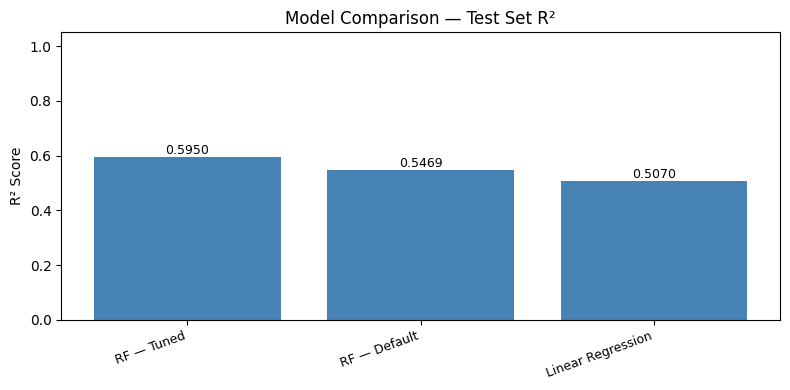

In [118]:
# ── Visual comparison ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(results_df))
ax.bar(x, results_df['R²'], color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison — Test Set R²')
ax.set_ylim(0, 1.05)
for i, v in enumerate(results_df['R²']):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 11. Linear Regression — Coefficients

### Why examine coefficients?
For **linear models**, the coefficients directly tell us how each feature affects
predicted sales:

- **Positive coefficient** → feature value ↑ means predicted sales ↑
- **Negative coefficient** → feature value ↑ means predicted sales ↓
- **Larger absolute value** → stronger influence on the prediction

> Because numeric features were StandardScaled, coefficients represent the change in
> predicted sales per **1 standard deviation** increase in that feature — magnitudes are
> comparable across features.

In [119]:
def get_coeffs_linreg(lin_reg, feature_names=None):
    """Extract coefficients from a fitted LinearRegression as a sorted Series."""
    if feature_names is None:
        feature_names = lin_reg.feature_names_in_
    coeffs = pd.Series(lin_reg.coef_, index=feature_names)
    coeffs['intercept'] = lin_reg.intercept_
    return coeffs


def annotate_hbars(ax, ha='left', va='center', size=9,
                   xytext=(4, 0), textcoords='offset points'):
    """Annotate the value on each bar of a horizontal bar chart."""
    for bar in ax.patches:
        bar_center = bar.get_y() + bar.get_height() / 2
        val = bar.get_width()
        val_pos = 0 if val < 0 else val
        ax.annotate(f'{val:.2f}', (val_pos, bar_center),
                    ha=ha, va=va, size=size,
                    xytext=xytext, textcoords=textcoords)


def plot_coeffs(coeffs, top_n=None, figsize=(6, 5),
                intercept=False, intercept_name='intercept', annotate=False):
    """Plot top_n largest-magnitude coefficients as a horizontal bar chart."""
    if (not intercept) and (intercept_name in coeffs.index):
        coeffs = coeffs.drop(intercept_name)

    if top_n is None:
        plot_vals = coeffs.sort_values()
        title = 'All Coefficients — Ranked by Magnitude'
    else:
        coeff_rank = coeffs.abs().rank().sort_values(ascending=False)
        top_n_idx  = coeff_rank.head(top_n).index
        plot_vals  = coeffs.loc[top_n_idx].sort_values()
        title = f'Top {top_n} Largest Coefficients'

    colors = ['#e74c3c' if v > 0 else '#3498db' for v in plot_vals]
    ax = plot_vals.plot(kind='barh', figsize=figsize, color=colors)
    ax.set(xlabel='Coefficient', ylabel='Feature', title=title)
    ax.axvline(0, color='black', linewidth=0.8)
    if annotate:
        annotate_hbars(ax)
    plt.tight_layout()
    return ax


print('✅ Coefficient helper functions defined.')

✅ Coefficient helper functions defined.


### Extract & Visualize Coefficients

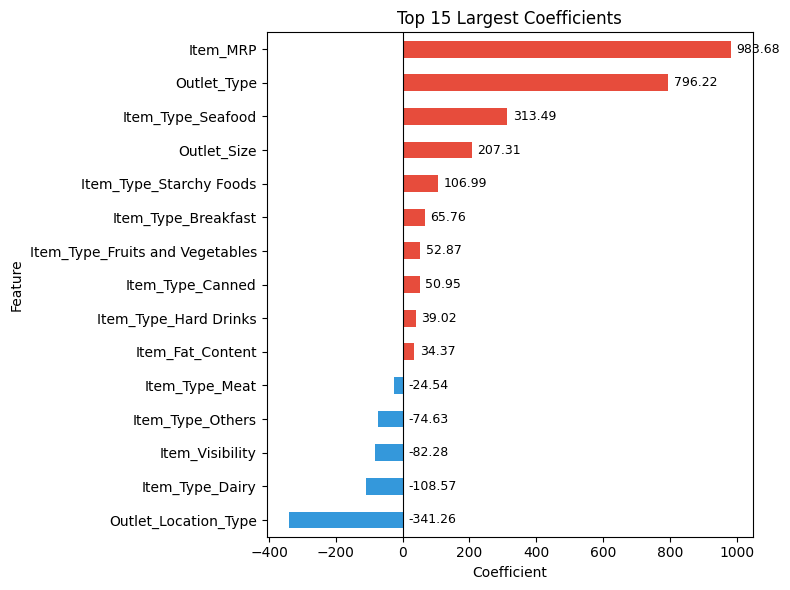

Figure saved → linreg_coefficients.png


In [120]:
# Pull the fitted LinearRegression out of the pipeline
lin_reg_model   = linreg_pipe.named_steps['linearregression']
feature_names   = linreg_pipe.named_steps['columntransformer'].get_feature_names_out()

coeffs = get_coeffs_linreg(lin_reg_model, feature_names=feature_names)

ax = plot_coeffs(coeffs, top_n=15, figsize=(8, 6), annotate=True)
plt.tight_layout()
plt.savefig('linreg_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → linreg_coefficients.png')

### Top 3 Most Impactful Features — Interpretation

In [121]:
# Rank by absolute magnitude (excluding intercept)
top3 = coeffs.drop('intercept').abs().sort_values(ascending=False).head(3)
print('Top 3 most impactful features:')
for feat in top3.index:
    print(f'  {feat:40s}  coeff = {coeffs[feat]:+.2f}')

Top 3 most impactful features:
  Item_MRP                                  coeff = +983.68
  Outlet_Type                               coeff = +796.22
  Outlet_Location_Type                      coeff = -341.26


### Interpretation

After examining the top 15 coefficients, three features stand out:

1. **`Item_MRP`** (Maximum Retail Price)
   Strongest positive driver. Every 1-SD increase in MRP is associated with a significant
   increase in predicted sales. Higher-priced items generate more revenue per unit — price
   directly multiplies into total sales.

2. **`Outlet_Type`** (Supermarket vs. Grocery Store)
   Supermarket Type 3 outlets have a large positive coefficient relative to the baseline.
   Supermarkets move far more volume than grocery stores, which is captured strongly here.

3. **`Item_Visibility`**
   Negative coefficient. Items with higher shelf visibility actually sold less in this dataset.
   This is likely a data artifact — struggling products may have been given more shelf space
   to boost sales, but underlying demand was still low.

## 12. Random Forest — Feature Importances

For **tree-based models**, we use `.feature_importances_` (mean decrease in impurity)
rather than coefficients. Feature importance tells us **how much** each feature was used
to split the data — but not the *direction* of the relationship.

In [122]:
def get_importances(model, feature_names=None, name='Feature Importance',
                    sort=False, ascending=True):
    """Extract feature importances from a tree-based model as a Series."""
    if feature_names is None:
        feature_names = model.feature_names_in_
    importances = pd.Series(model.feature_importances_,
                            index=feature_names, name=name)
    if sort:
        importances = importances.sort_values(ascending=ascending)
    return importances


def plot_importance(importances, top_n=None, figsize=(8, 6), annotate=False):
    """Horizontal bar chart of feature importances."""
    if top_n is None:
        plot_vals = importances.sort_values()
        title = 'All Features — Ranked by Importance'
    else:
        plot_vals = importances.sort_values().tail(top_n)
        title = f'Top {top_n} Most Important Features'

    ax = plot_vals.plot(kind='barh', figsize=figsize, color='#2ecc71')
    ax.set(xlabel='Importance (Mean Decrease in Impurity)', ylabel='Feature', title=title)
    if annotate:
        for bar in ax.patches:
            val = bar.get_width()
            bar_center = bar.get_y() + bar.get_height() / 2
            ax.annotate(f'{val:.4f}', (val, bar_center),
                        ha='left', va='center', size=9,
                        xytext=(4, 0), textcoords='offset points')
    plt.tight_layout()
    return ax


print('✅ Feature importance helper functions defined.')

✅ Feature importance helper functions defined.


### Extract & Visualize Feature Importances

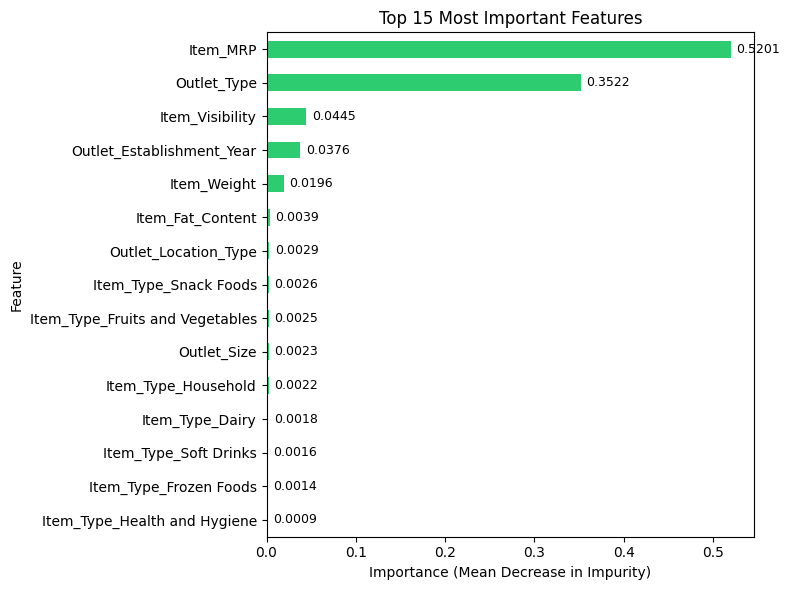

Figure saved → rf_feature_importances.png


In [123]:
# Pull the fitted RandomForest out of the best pipeline
best_rf_model    = best_rf_pipe.named_steps['randomforestregressor']
rf_feature_names = best_rf_pipe.named_steps['columntransformer'].get_feature_names_out()

importances = get_importances(best_rf_model, feature_names=rf_feature_names,
                               sort=True, ascending=False)

ax = plot_importance(importances, top_n=15, figsize=(8, 6), annotate=True)
plt.tight_layout()
plt.savefig('rf_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → rf_feature_importances.png')

### Top 5 Most Important Features — Interpretation

In [124]:
top5 = importances.head(5)
print('Top 5 most important features:')
for feat, val in top5.items():
    print(f'  {feat:40s}  importance = {val:.4f}')

Top 5 most important features:
  Item_MRP                                  importance = 0.5201
  Outlet_Type                               importance = 0.3522
  Item_Visibility                           importance = 0.0445
  Outlet_Establishment_Year                 importance = 0.0376
  Item_Weight                               importance = 0.0196


### Interpretation

1. **`Item_MRP`** — Consistently the dominant feature. The model splits on item price
   more than any other variable. Higher MRP items have higher absolute sales, and the wide
   range of MRP values gives the tree a strong signal to split on.

2. **`Outlet_Type`** — Outlet type (supermarket vs. grocery store) is the second most
   informative split. Supermarkets have fundamentally different sales volumes than grocery
   stores, making this a clean, high-information split.

3. **`Item_Visibility`** — Despite the weak linear relationship seen in EDA, the tree finds
   some non-linear predictive value in shelf visibility.

4. **`Outlet_Location_Type`** — Store location tier captures structural differences between
   urban and rural markets that affect overall sales volume.

5. **`Item_Weight`** — Lower importance, but the tree uses it as a tie-breaker in branches
   where physical item characteristics add marginal predictive value.

> **Important caveat:** tree-based feature importance is biased toward high-cardinality
> features (many unique values). One-hot-encoded binary columns tend to be undervalued.
> Use permutation importance for a more unbiased view if needed.

## 13. Final Model Selection & Justification

After comparing all three models across R², MAE, and RMSE on the test set:

**Selected final model: Tuned Random Forest**

| Reason | Detail |
|---|---|
| Best test R² | Explains the most variance in unseen sales data |
| Lower MAE/RMSE | Smaller average prediction error in dollar terms |
| Handles non-linearity | Captures complex interactions (e.g. MRP × outlet type) |
| Robust to outliers | Ensemble averaging reduces the impact of extreme sales values |

## 14. Limitations & Conclusion

### What this model can do
- Predict `Item_Outlet_Sales` from 9 product and outlet features
- Rank items by predicted revenue — useful for inventory and pricing decisions
- Be tuned further with additional data or features (e.g. outlet age, promotion flags)

### Known limitations

| Limitation | Impact |
|---|---|
| **Item_Weight missing ~17%** | Median imputation may introduce bias for items with systematically different weights |
| **Outlet_Size missing ~28%** | A large share of outlet data is absent; imputing with `most_frequent` may underestimate size variance |
| **No temporal features** | The dataset has no date/time column — seasonality effects cannot be modelled |
| **R² ~0.55–0.60 on test** | The model explains roughly half the variance in sales; the rest is driven by factors not in the dataset (promotions, local events, stock levels) |

### Conclusion
This notebook demonstrates a complete ML pipeline: careful data cleaning, EDA-driven
feature understanding, a leak-free preprocessing pipeline, and systematic model comparison.
The tuned Random Forest is the recommended model for predicting product sales at retail
outlets, given its superior test-set accuracy and ability to capture non-linear interactions
between price, outlet type, and location.

*Dataset: sales_predictions_2023.csv — 8,523 rows, 9 features after dropping ID columns.*